# T015 · 蛋白质-配体对接

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Jaime Rodríguez-Guerra, 2019-2020, [Volkamer 实验室](https://volkamerlab.org/)
- Dominique Sydow, 2019-2020, [Volkamer 实验室](https://volkamerlab.org/)
- Michele Wichmann, 2020, [Volkamer 实验室](https://volkamerlab.org/)


## 本教程的目标

在本教程中，我们将使用分子对接来预测小分子在蛋白质结合位点中的结合模式。表皮生长因子受体（[EGFR](https://www.uniprot.org/uniprot/P00533)）将作为我们的靶标蛋白。我们尝试将已知的 EGFR 抑制剂重新对接（re-dock）到 EGFR 的结合位点中，以重现实验中观察到的结合模式。


### _理论_ 部分内容

- 分子对接
- 采样算法
- 评分函数
- 局限性
- 视觉检查
- 对接软件
  - 商业软件
  - 免费软件（面向学术界）


### _实践_ 部分内容

- 蛋白质和配体的准备
- 结合位点定义
- 对接计算
- 对接结果可视化


### 参考文献
- 分子对接：
    - Pagadala _等_, [_Biophy Rev_ (2017), __9__, 91-102](https://doi.org/10.1007/s12551-016-0247-1)
    - Meng _等_, [_Curr Comput Aided Drug Des_ (2011), __7__, 2, 146-157](https://doi.org/10.2174/157340911795677602)
- 对接着眼点：
    - Fischer _等_, [_J. Chem. Inf. Model._ (2021), __61__, 12, 5716-5729](https://pubs.acs.org/doi/10.1021/acs.jcim.1c00698)
- Smina 对接程序：
    - Koes _等_, [_J Chem Inf Model_ (2013), __53__, 8, 1893-1904](https://doi.org/10.1021/ci300604z)
- NGLView 用于对接可视化：
    - Nguyen _等_, [_Bioinformatics_ (2018), __34__, 7, 1241-1242](https://doi.org/10.1093/bioinformatics/btx789)
- OpenBabel：
    - O'Boyle _等_, [_J Cheminform_ (2011), __3__, 33](https://doi.org/10.1186/1758-2946-3-33)


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 15
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt
    %conda install openbabel smina -y -c conda-forge

## 理论


### 分子对接

在现代药物发现流程中，确定活性分子与给定蛋白质靶标的结合模式至关重要。这些信息可以指导新的化学修饰，以优化靶标蛋白与配体之间的相互作用。基于计算机的方法，即**分子对接**，可用于预测小分子在蛋白质结合口袋中的结合模式。

简而言之（图 1）：

* 我们拥有蛋白质的三维结构（通常通过 X 射线晶体学或 NMR 获得）。
* 我们拥有一个潜在配体（小分子）的化学结构。
* 使用该领域的专用软件，我们尝试确定配体在结合位点中的最佳化学构象和空间朝向。

![Docking overview](images/docking.png)

*图 1：* 分子对接原理（图由 Dominique Sydow 提供）。


**分子对接工作流**通常包含以下步骤（图 2）：

- 输入文件准备，例如质子化和转换为特定文件格式
- 在结合口袋内对配体进行构象采样
- 对采样构象进行评分

![Docking workflow](images/docking_workflow.png)

*图 2：* 分子对接工作流（图由 Dominique Sydow 提供）。


### 采样算法

目前大多数可用的分子对接工具使用以下一种或多种算法来对蛋白质结合口袋中配体的构象进行采样（[_Curr Comput Aided Drug Des_ (2011), __7__, 2, 146-157](https://doi.org/10.2174/157340911795677602)）：

* **形状互补性**：使用基于片段的方法对配体-受体的几何互补性进行采样（例如 DOCK, FRED）
* **系统搜索**：对分子的所有自由度进行系统采样，以列举配体的可能构象（例如 Glide, eHITS）
* **随机搜索**：随机改变配体的构象（例如 AutoDock, Gold, MOE）
  * 蒙特卡洛（Monte Carlo, MC）
  * 遗传算法（Genetic Algorithm, GA）


### 评分函数

评分函数用于区分正确和错误的对接姿势，即优先选择活性分子而非非活性分子。评分函数需要尽可能精确，同时应消耗较少的计算资源。目前有两种主要的评分函数类型：

* **基于力场**：基于参数的函数，使用原子坐标来估算蛋白质-配体结合能，例如 DOCK、Gold。
* **经验性**：基于参数的函数，使用可训练的数据集来拟合实验数据，例如 AutoDock、Glide、Smina。

一些对接软件支持使用来自不同评分函数的共识评分（consensus scoring），以增加识别真实结合模式的概率。


ℹ **提示**：可以查看 Schrödinger 提供的这些培训视频，以回顾[药物-靶标相互作用](https://www.youtube.com/watch?v=u49k72rUdyc)和[蛋白质-配体对接](https://www.schrodinger.com/training/videos/small-molecule-drug-discovery/hands-demo-covalent-docking-maestro)的可视化演示。


### 局限性

* 对接程序可以在对接计算过程中将某些残基侧链视为柔性，以考虑结合口袋的灵活性。然而，蛋白质-配体结合的动态性和适应性在对接计算中难以得到充分的探索。
* 目前可用的评分函数通常对于对接姿势排名和虚拟筛选来说还不够精确。
* 配体的质子化对对接结果有很大影响，但大多数对接程序需要预先定义的质子化状态。
* 在对接过程中，共晶水分子通常被去除，尽管它们可能对结合过程至关重要。
* 由于缺乏足够且一致的结构训练数据，涉及非锌类金属的金属配位难以正确处理。


### 视觉检查

由于前述采样算法和对接评分函数的局限性，在大多数对接场景中，视觉检查是常规步骤。有趣的是，一项调查显示，分子建模专家在识别真实的结合模式时优于评分函数（[_J. Med. Chem._ (2014), __57__, 7, 2817-2825](https://doi.org/10.1021/jm4011029)），即使视觉检查在对接结果数量很大的情况下存在已知瓶颈。

在本教程中，我们通过将共晶配体重新对接到其结合位点来评估对接程序，即评估是否能重现实验观察到的结合模式。


### 对接软件

以下列举了几个有代表性的对接程序，并根据其免费许可的可用性进行了分类。更全面的列表可以在 [Wikipedia](https://en.wikipedia.org/wiki/List_of_protein-ligand_docking_software) 找到。

**商业软件**：

* [Schrödinger Glide](https://www.schrodinger.com/glide)
* [CCDC Gold](https://www.ccdc.cam.ac.uk/solutions/csd-discovery/Components/Gold/)
* [Chemical Computing Group MOE](https://www.chemcomp.com/Products.htm)

**对学术界免费**：

* [AutoDock](http://autodock.scripps.edu/)
* AutoDock Vina（[论文](https://doi.org/10.1002/jcc.21334)、[网站](http://vina.scripps.edu/)）
* Smina（[论文](https://doi.org/10.1021/ci300604z)、[网站](https://sourceforge.net/projects/smina/)）
* [AutoDockFR](https://ccsb.scripps.edu/adfr/)
* [OpenEye](https://www.eyesopen.com/)（部分免费）


## 实践

在本教程中，我们将使用对接软件 [Smina](https://sourceforge.net/projects/smina/) 将共晶配体重新对接到 EGFR 的蛋白质结合口袋中。

* Smina（[_J Chem Inf Model_ (2013), __53__, 8, 1893-1904](https://doi.org/10.1021/ci300604z)）是 AutoDock Vina 的一个分支，具有改进的评分功能和能量最小化算法。默认情况下，它使用了一种自定义的经验评分函数，但也支持用户自定义的评分函数。Smina 是基于命令行使用的，提供了许多自定义参数，我们可以使用 Python 进行封装，将其集成到我们的工作流中。
* 我们将使用 [OpenBabel](http://openbabel.org) 的 Python 接口 `pybel` 来准备蛋白质和配体结构（为对接计算做准备）。
* 可视化在 [NGLView](http://nglviewer.org/nglview/latest/) 的帮助下完成。

我们使用 EGFR 与共晶配体 IRE（[PDB ID: 2ito](https://www.rcsb.org/structure/2ITO)）作为示例结构，并尝试重现其结合模式。


In [3]:
# 导入库
import warnings
from pathlib import Path
import subprocess

import nglview as nv
from openbabel import pybel

from opencadd.structure.core import Structure

In [4]:
# 过滤警告信息
warnings.filterwarnings("ignore")
ob_log_handler = pybel.ob.OBMessageHandler()
pybel.ob.obErrorLog.SetOutputLevel(0)

In [5]:
# 定义路径
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 蛋白质与配体的准备

基于 AutoDock 套件的程序要求蛋白质和配体以 `PDBQT` 格式准备。这种文件格式与 PDB 格式非常相似，但额外存储了原子类型和部分电荷的信息。在 AutoDock 套件中，这些信息用于评分函数来评估蛋白质-配体相互作用。在将 PDB 和 SMILES 格式转换为 PDBQT 格式之前，需要进行一些准备步骤，例如根据给定的 pH 值设置正确的质子化状态。我们将使用 `pybel`（OpenBabel 的 Python 接口）来完成这一任务。


In [6]:
# 从蛋白质数据银行获取结构
pdb_id = "2ito"
structure = Structure.from_pdbid(pdb_id)
# 元素信息可能缺失，但对后续 PDBQT 转换很重要
if not hasattr(structure.atoms, "elements"):
    structure.add_TopologyAttr("elements", structure.atoms.types)
structure
# NBVAL_CHECK_OUTPUT

<Universe with 2484 atoms>

**准备蛋白质**


In [7]:
# 将蛋白质文件写入磁盘
protein = structure.select_atoms("protein")
protein.write(DATA / "protein.pdb")

In [8]:
def pdb_to_pdbqt(pdb_path, pdbqt_path, pH=7.4):
    """
    将 PDB 文件转换为 AutoDock 系列对接程序所需的 PDBQT 文件。

    Parameters
    ----------
    pdb_path：str 或 pathlib.Path
        输入 PDB 文件的路径。
    pdbqt_path：str 或 pathlib.Path
        输出的 PDBQT 文件路径。
    pH: float
        Protonation at given pH.
    """
    molecule = list(pybel.readfile("pdb", str(pdb_path)))[0]
    # add hydrogens at given pH
    molecule.OBMol.CorrectForPH(pH)
    molecule.addh()
    # add partial charges to each atom
    for atom in molecule.atoms:
        atom.OBAtom.GetPartialCharge()
    molecule.write("pdbqt", str(pdbqt_path), overwrite=True)
    return

In [9]:
# 将蛋白质转换为 PDBQT 格式
pdb_to_pdbqt(DATA / "protein.pdb", DATA / "protein.pdbqt")

**准备配体**

接下来，我们将处理配体的准备工作。由于我们希望将共晶配体重新对接到结合位点中，我们可以直接从蛋白质数据银行（Protein Data Bank）获取 SMILES 格式的配体（配体 ID：[IRE](https://www.rcsb.org/ligand/IRE)）。


In [10]:
# 定义目标蛋白质-配体复合物的配体 SMILES
smiles = "COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OCCCN4CCOCC4"

In [11]:
def smiles_to_pdbqt(smiles, pdbqt_path, pH=7.4):
    """
    将 SMILES 字符串转换为 AutoDock 系列对接程序所需的 PDBQT 文件。

    Parameters
    ----------
    smiles：str
        SMILES 字符串。
    pdbqt_path：str 或 pathlib.Path
        输出的 PDBQT 文件路径。
    pH: float
        Protonation at given pH.
    """
    molecule = pybel.readstring("smi", smiles)
    # add hydrogens at given pH
    molecule.OBMol.CorrectForPH(pH)
    molecule.addh()
    # generate 3D coordinates
    molecule.make3D(forcefield="mmff94s", steps=10000)
    # add partial charges to each atom
    for atom in molecule.atoms:
        atom.OBAtom.GetPartialCharge()
    molecule.write("pdbqt", str(pdbqt_path), overwrite=True)
    return

In [12]:
# 将配体转换为 PDBQT 格式
smiles_to_pdbqt(smiles, DATA / "ligand.pdbqt")

### 结合位点定义

理论上，可以考虑将整个蛋白质作为结合位点进行对接计算。然而，由于对接算法已知的局限性，通常建议将结合位点限制在对接程序搜索的主要区域。在这里，我们将配体 Ire 的结合口袋限制在距离共晶配体 14 Å 的范围内。

我们使用 `opencadd.structure` 中内置的功能来提取结合位点定义。


In [13]:
ligand_resname = "IRE"
ligand = structure.select_atoms(f"resname {ligand_resname}")
pocket_center = (ligand.positions.max(axis=0) + ligand.positions.min(axis=0)) / 2
pocket_size = ligand.positions.max(axis=0) - ligand.positions.min(axis=0) + 5

### 对接计算


最后，我们可以进行实际的对接计算了。Smina 是一个命令行工具，目前没有提供 Python API。

* 不过，我们可以编写一个函数，负责生成正确的命令并执行计算。
* 函数 `run_smina` 需要输入配体结构（PDBQT 格式）、蛋白质结构（PDBQT 格式）、蛋白质结合位点以及对接的 exhaustiveness（详尽性）参数。该函数返回安装了配体对接姿势的蛋白质结构。
* `smina` 可执行文件已经预装在 `teachopencadd` conda 环境中。因此，直接执行 `smina` 就可以像执行其他已安装命令一样。

**注意**：由于计算时间可能较长，我们生成的结果已经预先计算好并保存在 `data` 文件夹中。如果你想自己执行对接过程，请设置 `RUN_DOCKING = True`。


In [14]:
def run_smina(
    ligand_path, protein_path, out_path, pocket_center, pocket_size, num_poses=10, exhaustiveness=8
):
    """
    使用 Smina 进行对接。

    Parameters
    ----------
    ligand_path：str 或 pathlib.Path
        待对接的配体 PDBQT 文件路径。
    protein_path: str or pathlib.Path
        Path to protein PDBQT file that should be docked to.
    out_path: str or pathlib.Path
        Path to which docking poses should be saved, SDF or PDB format.
    pocket_center: iterable of float or int
        Coordinates defining the center of the binding site.
    pocket_size: iterable of float or int
        Lengths of edges defining the binding site.
    num_poses: int
        Maximum number of poses to generate.
    exhaustiveness: int
        Accuracy of docking calculations.

    Returns
    -------
    output_text: str
        The output of the Smina calculation.
    """
    output_text = subprocess.check_output(
        [
            "smina",
            "--ligand",
            str(ligand_path),
            "--receptor",
            str(protein_path),
            "--out",
            str(out_path),
            "--center_x",
            str(pocket_center[0]),
            "--center_y",
            str(pocket_center[1]),
            "--center_z",
            str(pocket_center[2]),
            "--size_x",
            str(pocket_size[0]),
            "--size_y",
            str(pocket_size[1]),
            "--size_z",
            str(pocket_size[2]),
            "--num_modes",
            str(num_poses),
            "--exhaustiveness",
            str(exhaustiveness),
        ],
        universal_newlines=True,  # needed to capture output text
    )
    return output_text

In [15]:
output_text = run_smina(
    DATA / "ligand.pdbqt",
    DATA / "protein.pdbqt",
    DATA / "docking_poses.sdf",
    pocket_center,
    pocket_size,
)
print(output_text)

   _______  _______ _________ _        _______ 
  (  ____ \(       )\__   __/( (    /|(  ___  )
  | (    \/| () () |   ) (   |  \  ( || (   ) |
  | (_____ | || || |   | |   |   \ | || (___) |
  (_____  )| |(_)| |   | |   | (\ \) ||  ___  |
        ) || |   | |   | |   | | \   || (   ) |
  /\____) || )   ( |___) (___| )  \  || )   ( |
  \_______)|/     \|\_______/|/    )_)|/     \|


smina is based off AutoDock Vina. Please cite appropriately.

Weights      Terms
-0.035579    gauss(o=0,_w=0.5,_c=8)
-0.005156    gauss(o=3,_w=2,_c=8)
0.840245     repulsion(o=0,_c=8)
-0.035069    hydrophobic(g=0.5,_b=1.5,_c=8)
-0.587439    non_dir_h_bond(g=-0.7,_b=0,_c=8)
1.923        num_tors_div

Using random seed: 480438074

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************

mode |   affinity | dist from best mode
     | (kcal/mol) | rmsd l.b.| rmsd u.b.
-----+------------+----------+----------
1

输出是一个包含对接姿势的文件，以及一个基于文本的对接结果描述，包括估计的亲和力以及每个姿势与亲和力预测最高的姿势之间的均方根偏差（RMSD）（[Vina 输出格式说明](http://vina.scripps.edu/manual.html)）。


In [16]:
(DATA / "docking_poses.sdf").exists()
# NBVAL_CHECK_OUTPUT

True

### 对接结果可视化

现在，让我们分析对接结果。我们是否能够重现实验解析结构中观察到的结合模式？

生成了多个结合姿势并保存为单个 SDF 文件。为了能够单独检查每个对接姿势，我们提供了一个辅助函数 `split_sdf_file` 来拆分该文件。我们将所有对接姿势以列表形式读入，并选择最佳的 N 个对接姿势显示在下方的 NGLView 查看器中。


In [17]:
def split_sdf_file(sdf_path):
    """
    将 SDF 文件拆分为每个分子各自的独立文件。
    每个文件以连续数字命名。

    Parameters
    ----------
    sdf_path：str 或 pathlib.Path
        待拆分的 SDF 文件路径。
    """
    sdf_path = Path(sdf_path)
    stem = sdf_path.stem
    parent = sdf_path.parent
    molecules = pybel.readfile("sdf", str(sdf_path))
    for i, molecule in enumerate(molecules, 1):
        molecule.write("sdf", str(parent / f"{stem}_{i}.sdf"), overwrite=True)
    return

In [18]:
split_sdf_file(DATA / "docking_poses.sdf")

在下一个单元中，我们可以分别可视化每个对接姿势，并将其与 X 射线结构中观察到的结合模式进行比较。你也可以提供包含所有配体的 SDF 文件，将它们一起可视化。共晶配体以原子着色（C：绿色）显示，而对接计算的配体则以橙色（C）显示。这些配体与蛋白质（灰色表面）结合位点叠加在一起。使用下拉菜单选择不同的对接姿势。


In [19]:
docking_pose_id = 1
view = nv.show_structure_file(
    str(DATA / f"docking_poses_{docking_pose_id}.sdf"),
    representations=[{"params": {}, "type": "licorice"}],
)
view.add_pdbid(pdb_id)
view

NGLWidget()

In [20]:
view.render_image(trim=True, factor=2);

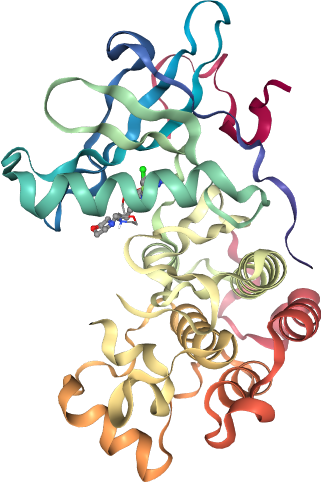

In [22]:
view._display_image()

通过提供的可视化，你现在可以检查对接程序是否能够重现 X 射线结构中观察到的结合模式。此外，你还可以检查评分最优的对接姿势（`docking_pose_id = 1`）是否比后续对接姿势更接近 X 射线结构。

总结：
- Docking pose 1（最佳评分）似乎与实验结果吻合得最好。
- Docking pose 2 的重原子在结合口袋中偏离了共晶位置。
- Docking pose 3 似乎完全翻转了方向。


## 讨论

通过结合使用三种免费软件工具（[OpenBabel](http://openbabel.org)、[Smina](https://sourceforge.net/projects/smina/)、[NGLView](http://nglviewer.org/nglview/latest/)），我们能够执行对接计算并在 Jupyter notebook 中可视化结果。这使我们可以评估对接软件是否能够重现实验观察到的结合模式。

对于本例（EGFR PDB: 2ito，配体 IRE），Smina 被证明在评分最佳的结合姿势中成功重现了配体 Ire 的实验结合模式。


## 测验

- 尝试通过 exhaustiveness 参数提高对接计算的精度。你看到任何改善吗？对所需的计算时间有何影响？
- 在蛋白质数据银行（Protein Data Bank）中搜索另一个蛋白质-配体复合物，将配体重新对接到其靶标蛋白中，并检查配体的实验结合模式是否能够被重现。
